# Notebook 07 — Static Gratings Validation

Cross-validates nb05d order-corrected Lindeberg parameters against orientation
and spatial frequency tuning from static gratings (Session A).

## Three predictions tested

| RF parameter | Grating measurement | Prediction |
|---|---|---|
| θ_hybrid (hybrid orientation) | Preferred orientation from tuning curve | θ_hybrid ≈ pref_ori |
| σ (spatial scale, degrees) | Preferred spatial frequency (cpd) | SF_pref ≈ 1/(2πσ) |
| κ (elongation) | Orientation bandwidth (FWHM) | Higher κ → narrower bandwidth |

## Session structure
- **Session C** (sparse noise) → RF maps → nb05d parameters  
- **Session A** (static gratings) → orientation + SF tuning curves → this notebook  
- Same container_id links the two sessions for each neuron

## Static gratings stimulus
- Orientations: 0°, 30°, 60°, 90°, 120°, 150° (30° spacing)
- Spatial frequencies: 0.02, 0.04, 0.08, 0.16, 0.32 cycles/degree
- Phase: 0, 0.25, 0.5, 0.75 (averaged over for tuning curves)
- Duration: 0.25 s per presentation


In [1]:
import sys, warnings, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, circmean, circstd
from scipy.optimize import curve_fit
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [2]:
# ---------------------------------------------------------------------------
# Paths — same structure as all previous notebooks
# ---------------------------------------------------------------------------
base_dir    = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir   = base_dir / 'data' / 'cache'
lists_dir   = base_dir / 'data' / 'experiment_lists'
outputs_dir = base_dir / 'outputs' / 'rf_params'
nb05d_dir   = outputs_dir / 'order_full'
nb07_dir    = base_dir / 'outputs' / 'gratings_validation'
nb07_dir.mkdir(parents=True, exist_ok=True)

manifest_path = str(cache_dir / 'manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_path)

# Load nb05d order-corrected parameters
nb05d_path = nb05d_dir / 'rf_params_order_all_containers.csv'
rf_df = pd.read_csv(nb05d_path)
for col in ['sigma', 'theta', 'kappa', 'theta_hybrid', 'phi',
            'phi_confidence', 'x0', 'y0', 'r_squared']:
    if col in rf_df.columns:
        rf_df[col] = pd.to_numeric(rf_df[col], errors='coerce')

print(f'nb05d RF parameters: {len(rf_df):,} neurons  |  '
      f'{rf_df["container_id"].nunique()} containers')
print(f'Order breakdown: {rf_df["derivative_order"].value_counts().sort_index().to_dict()}')

# Build container → Session A experiment_id map
batch_df  = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded = set(verify_df[verify_df['exists']]['experiment_id'].tolist())

session_a = batch_df[
    batch_df['session_type'].str.contains('B') &
    batch_df['id'].isin(downloaded)
].copy()

container_to_sessA = dict(zip(session_a['experiment_container_id'],
                               session_a['id']))
print(f'Session A experiments available: {len(container_to_sessA)}')

# Containers present in both nb05d and Session A
common_containers = set(rf_df['container_id'].unique()) & set(container_to_sessA.keys())
print(f'Containers with both RF and Session A data: {len(common_containers)}')


nb05d RF parameters: 885 neurons  |  17 containers
Order breakdown: {0: 477, 1: 99, 2: 309}
Session A experiments available: 17
Containers with both RF and Session A data: 17


In [15]:
# ---------------------------------------------------------------------------
# Tuning curve model functions
# ---------------------------------------------------------------------------

def von_mises_ori(theta_deg, R0, Rmax, mu_deg, kappa_vm):
    """von Mises orientation tuning on the projective line [0, 180°).

    Because orientation is π-periodic we use doubled angles:
        R(θ) = R0 + Rmax * exp(κ_vm * (cos(2(θ - μ)) - 1))

    Parameters
    ----------
    theta_deg : array  orientation in degrees
    R0        : float  baseline response
    Rmax      : float  peak response above baseline
    mu_deg    : float  preferred orientation in degrees
    kappa_vm  : float  concentration (higher = narrower)

    Returns
    -------
    Predicted response (same shape as theta_deg).
    """
    theta_rad = np.deg2rad(theta_deg)
    mu_rad    = np.deg2rad(mu_deg)
    return R0 + Rmax * np.exp(kappa_vm * (np.cos(2 * (theta_rad - mu_rad)) - 1))


def ori_bandwidth_from_kappa_vm(kappa_vm):
    """FWHM orientation bandwidth in degrees from von Mises κ.

    Solve exp(κ(cos(2Δ) - 1)) = 0.5 for Δ:
        Δ = 0.5 * arccos(1 + ln(0.5)/κ)
    FWHM = 2 * Δ converted to degrees.
    Returns NaN if κ is too small (very broad tuning).
    """
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        arg = 1 + np.log(0.5) / np.maximum(kappa_vm, 1e-6)
        arg = np.clip(arg, -1, 1)
        half_width_rad = 0.5 * np.arccos(arg)
    return float(np.rad2deg(2 * half_width_rad))


def gaussian_sf(log2_sf, R0, Rmax, mu_log2, sigma_log2):
    """Log-Gaussian SF tuning.

    R(f) = R0 + Rmax * exp(-(log2(f) - mu)² / (2 σ²))
    Fit in log2-SF space — standard for V1 SF tuning.
    """
    return R0 + Rmax * np.exp(-(log2_sf - mu_log2)**2 / (2 * sigma_log2**2))


print('Model functions defined')
print('  von_mises_ori: R(θ) = R0 + Rmax·exp(κ(cos(2(θ−μ))−1))')
print('  gaussian_sf  : R(f) = R0 + Rmax·exp(−(log₂f − μ)²/2σ²)')
print('  ori_bandwidth_from_kappa_vm: FWHM from κ_vm')


Model functions defined
  von_mises_ori: R(θ) = R0 + Rmax·exp(κ(cos(2(θ−μ))−1))
  gaussian_sf  : R(f) = R0 + Rmax·exp(−(log₂f − μ)²/2σ²)
  ori_bandwidth_from_kappa_vm: FWHM from κ_vm


In [16]:
# ---------------------------------------------------------------------------
# extract_grating_tuning — one dataset → per-cell tuning params
# ---------------------------------------------------------------------------
STATIC_GRATING_ORIENTATIONS  = np.array([0., 30., 60., 90., 120., 150.])
STATIC_GRATING_FREQUENCIES   = np.array([0.02, 0.04, 0.08, 0.16, 0.32])


def extract_grating_tuning(dataset, cell_ids,
                            response_delay_s=0.066,
                            response_window_s=0.25):
    """Extract orientation and SF tuning curves from static gratings.

    Strategy:
    1. Load stimulus table for 'static_gratings'.
    2. For each presentation compute mean ΔF/F in the response window.
    3. Average responses by (orientation, sf) condition.
    4. For orientation tuning: marginalise over SF (take best SF).
    5. For SF tuning: marginalise over orientation (take best orientation).
    6. Fit von Mises to orientation curve; log-Gaussian to SF curve.

    Returns
    -------
    list of dicts, one per cell, with keys:
        cell_id, pref_ori, ori_bandwidth, osi,
        pref_sf, sf_bandwidth, sf_r_squared,
        ori_r_squared, ori_kappa_vm,
        mean_responses_ori, mean_responses_sf   (arrays for plotting)
    """
    stim_name = 'static_gratings'
    if stim_name not in dataset.list_stimuli():
        raise ValueError('No static_gratings stimulus in this session.')

    stim_table = dataset.get_stimulus_table(stim_name)
    meta = dataset.get_metadata()
    frame_rate = (meta.get('ophys_frame_rate') or
              meta.get('frame_rate') or
              meta.get('imaging_frame_rate') or
              30.0)  # Allen 2P is always ~30 Hz — safe fallback

    delay_frames  = int(round(response_delay_s  * frame_rate))
    window_frames = int(round(response_window_s * frame_rate))

    # Single NWB read for all cells
    exp_cells     = list(dataset.get_cell_specimen_ids())  # NWB order — always valid
    req_set       = set(int(c) for c in cell_ids)
    valid_ids     = [c for c in exp_cells if c in req_set]  # our cells in NWB order

    _, all_dff = dataset.get_dff_traces(cell_specimen_ids=exp_cells)  # load ALL
    n_cells, n_tp = all_dff.shape
    cell_index = {cid: i for i, cid in enumerate(exp_cells)}  # index into full array

    # Response per presentation
    starts = stim_table['start'].values.astype(int)
    oris   = stim_table['orientation'].values.astype(float)
    sfs    = stim_table['spatial_frequency'].values.astype(float)
    # blank presentations have NaN orientation in the AllenSDK table
    valid  = np.isfinite(oris) & np.isfinite(sfs)

    win_idx  = (starts + delay_frames)[:, None] + np.arange(window_frames)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)

    # (n_cells, n_pres, window) → mean over window → (n_pres, n_cells)
    dff_wins = all_dff[:, win_safe]          # (n_cells, n_pres, window)
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T       # (n_pres, n_cells)

    results = []
    for cid in cell_ids:
        ci  = cell_index[int(cid)]
        rec = {'cell_id': int(cid)}

        try:
            resp = Y[:, ci]

            # ── Orientation tuning (marginalised over SF) ──────────────────
            ori_means = []
            for ori in STATIC_GRATING_ORIENTATIONS:
                mask = valid & (np.abs(oris - ori) < 1)
                ori_means.append(float(np.nanmean(resp[mask])) if mask.sum() > 0
                                 else np.nan)
            ori_means = np.array(ori_means)
            rec['mean_responses_ori'] = ori_means

            if np.all(np.isnan(ori_means)) or np.nanmax(ori_means) < 0:
                rec.update({'pref_ori': np.nan, 'ori_bandwidth': np.nan,
                            'osi': np.nan, 'ori_r_squared': np.nan,
                            'ori_kappa_vm': np.nan})
            else:
                # von Mises fit
                valid_ori = np.isfinite(ori_means)
                pref_idx  = int(np.nanargmax(ori_means))
                p0 = [float(np.nanmin(ori_means)),
                      float(np.nanmax(ori_means) - np.nanmin(ori_means)),
                      float(STATIC_GRATING_ORIENTATIONS[pref_idx]),
                      2.0]
                try:
                    popt, _ = curve_fit(
                        von_mises_ori,
                        STATIC_GRATING_ORIENTATIONS[valid_ori],
                        ori_means[valid_ori],
                        p0=p0,
                        bounds=([0, 0, -10, 0.01], [np.inf, np.inf, 190, 50]),
                        maxfev=5000)
                    R0_f, Rmax_f, mu_f, kappa_f = popt
                    fitted = von_mises_ori(STATIC_GRATING_ORIENTATIONS, *popt)
                    ss_res = np.nansum((ori_means[valid_ori] -
                                       fitted[valid_ori])**2)
                    ss_tot = np.nansum((ori_means[valid_ori] -
                                       ori_means[valid_ori].mean())**2)
                    ori_r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
                    pref_ori  = float(mu_f % 180)
                    bandwidth = ori_bandwidth_from_kappa_vm(kappa_f)
                    # OSI: (Rpref - Rorth) / (Rpref + Rorth)
                    orth_idx  = (pref_idx + 3) % 6
                    osi = float((ori_means[pref_idx] - ori_means[orth_idx]) /
                                (ori_means[pref_idx] + ori_means[orth_idx] + 1e-10))
                except Exception:
                    pref_ori  = float(STATIC_GRATING_ORIENTATIONS[pref_idx])
                    bandwidth = np.nan
                    ori_r2    = np.nan
                    kappa_f   = np.nan
                    osi       = np.nan
                rec.update({'pref_ori': pref_ori, 'ori_bandwidth': bandwidth,
                            'osi': osi, 'ori_r_squared': ori_r2,
                            'ori_kappa_vm': float(kappa_f)
                                           if np.isfinite(kappa_f) else np.nan})

            # ── SF tuning (at preferred orientation) ─────────────────────
            pref_ori_idx = int(np.nanargmax(ori_means)) if np.any(np.isfinite(ori_means)) else 0
            pref_ori_val = STATIC_GRATING_ORIENTATIONS[pref_ori_idx]
            sf_means = []
            for sf in STATIC_GRATING_FREQUENCIES:
                mask = valid & (np.abs(oris - pref_ori_val) < 1) &                                (np.abs(sfs - sf) < 0.001)
                sf_means.append(float(np.nanmean(resp[mask])) if mask.sum() > 0
                                else np.nan)
            sf_means = np.array(sf_means)
            rec['mean_responses_sf'] = sf_means

            if np.all(np.isnan(sf_means)) or np.nanmax(sf_means) < 0:
                rec.update({'pref_sf': np.nan, 'sf_bandwidth': np.nan,
                            'sf_r_squared': np.nan})
            else:
                valid_sf  = np.isfinite(sf_means)
                pref_sf_i = int(np.nanargmax(sf_means))
                log2_sfs  = np.log2(STATIC_GRATING_FREQUENCIES)
                p0_sf = [float(np.nanmin(sf_means)),
                         float(np.nanmax(sf_means) - np.nanmin(sf_means)),
                         float(log2_sfs[pref_sf_i]),
                         1.0]
                try:
                    popt_sf, _ = curve_fit(
                        gaussian_sf,
                        log2_sfs[valid_sf], sf_means[valid_sf],
                        p0=p0_sf,
                        bounds=([-np.inf, 0, -10, 0.1],
                                [np.inf, np.inf, 5, 5]),
                        maxfev=5000)
                    fitted_sf = gaussian_sf(log2_sfs, *popt_sf)
                    ss_res_sf = np.nansum((sf_means[valid_sf] -
                                          fitted_sf[valid_sf])**2)
                    ss_tot_sf = np.nansum((sf_means[valid_sf] -
                                          sf_means[valid_sf].mean())**2)
                    sf_r2     = 1 - ss_res_sf/ss_tot_sf if ss_tot_sf > 0 else 0.0
                    pref_sf   = float(2**popt_sf[2])  # back to cpd
                    sf_bw     = float(popt_sf[3])     # σ in octaves
                except Exception:
                    pref_sf = float(STATIC_GRATING_FREQUENCIES[pref_sf_i])
                    sf_bw   = np.nan
                    sf_r2   = np.nan
                rec.update({'pref_sf': pref_sf, 'sf_bandwidth': sf_bw,
                            'sf_r_squared': sf_r2})

        except Exception as e:
            warnings.warn(f'Cell {cid}: {e}')
            rec.update({'pref_ori': np.nan, 'ori_bandwidth': np.nan,
                        'osi': np.nan, 'ori_r_squared': np.nan,
                        'ori_kappa_vm': np.nan,
                        'pref_sf': np.nan, 'sf_bandwidth': np.nan,
                        'sf_r_squared': np.nan,
                        'mean_responses_ori': np.full(6, np.nan),
                        'mean_responses_sf':  np.full(5, np.nan)})

        results.append(rec)
    return results


print('extract_grating_tuning defined')


extract_grating_tuning defined


In [17]:
import traceback

# ---------------------------------------------------------------------------
# Full extraction loop — crash-safe per-container CSV
# ---------------------------------------------------------------------------
ORI_R2_THRESHOLD = 0.3   # minimum von Mises R² to trust pref_ori
t_start = time.time()

for container_id in sorted(common_containers):
    out_file = nb07_dir / f'grating_tuning_container_{container_id}.csv'
    if out_file.exists():
        df_ex = pd.read_csv(out_file)
        print(f'  [SKIP] Container {container_id}: {len(df_ex)} neurons (cached)')
        continue

    exp_id_a = container_to_sessA[container_id]
    # Cell IDs to query = those we have RF params for in this container
    cids_in_container = rf_df[rf_df['container_id'] == container_id]['cell_id']                             .astype(int).tolist()
    if not cids_in_container:
        print(f'  [SKIP] Container {container_id}: no RF neurons')
        continue

    print(f'\n  Container {container_id}  Sess-A exp {exp_id_a}'
          f'  ({len(cids_in_container)} RF neurons) …', flush=True)
    t0 = time.time()

    try:
        dataset = boc.get_ophys_experiment_data(exp_id_a)
        # Intersect with cells actually present in Session A
        sessA_cells = set(dataset.get_cell_specimen_ids())
        cell_ids    = [c for c in cids_in_container if c in sessA_cells]
        print(f'    {len(cell_ids)}/{len(cids_in_container)} cells present in Sess-A')

        if not cell_ids:
            print('    No overlap — skipping')
            continue

        results = extract_grating_tuning(dataset, cell_ids)
        print(f'    Extraction done in {time.time()-t0:.1f}s', flush=True)
    except Exception as e:
        print(f'    [FAIL] {e}')
        traceback.print_exc()
        continue

    # Flatten (drop raw tuning curve arrays before saving)
    rows = []
    for rec in results:
        rows.append({k: v for k, v in rec.items()
                     if k not in ('mean_responses_ori', 'mean_responses_sf')})
    if rows:
        pd.DataFrame(rows).to_csv(out_file, index=False)
        print(f'    Saved {len(rows)} neurons  ({time.time()-t0:.1f}s total)')

print(f'\nTotal: {(time.time()-t_start)/60:.1f} min')


  [SKIP] Container 511507650: 29 neurons (cached)
  [SKIP] Container 511509529: 25 neurons (cached)
  [SKIP] Container 511510650: 7 neurons (cached)
  [SKIP] Container 511510670: 26 neurons (cached)
  [SKIP] Container 511510718: 24 neurons (cached)
  [SKIP] Container 511510736: 19 neurons (cached)
  [SKIP] Container 511510855: 39 neurons (cached)
  [SKIP] Container 650389885: 16 neurons (cached)
  [SKIP] Container 652842570: 50 neurons (cached)
  [SKIP] Container 653125128: 38 neurons (cached)
  [SKIP] Container 661437138: 28 neurons (cached)
  [SKIP] Container 661732156: 57 neurons (cached)
  [SKIP] Container 666589599: 23 neurons (cached)
  [SKIP] Container 680156909: 44 neurons (cached)
  [SKIP] Container 682734790: 36 neurons (cached)
  [SKIP] Container 688678764: 59 neurons (cached)
  [SKIP] Container 701412138: 25 neurons (cached)

Total: 0.0 min


In [18]:
# ---------------------------------------------------------------------------
# Load all per-container CSVs and merge with nb05d RF parameters
# ---------------------------------------------------------------------------
csv_files = sorted(nb07_dir.glob('grating_tuning_container_*.csv'))
print(f'Found {len(csv_files)} grating tuning files')

gt_dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    if 'container_id' not in df.columns:
        df['container_id'] = int(f.stem.split('_')[-1])
    gt_dfs.append(df)

gt_df = pd.concat(gt_dfs, ignore_index=True)
for col in ['pref_ori', 'ori_bandwidth', 'osi', 'ori_r_squared',
            'pref_sf', 'sf_bandwidth', 'sf_r_squared', 'ori_kappa_vm']:
    gt_df[col] = pd.to_numeric(gt_df[col], errors='coerce')

print(f'Grating tuning: {len(gt_df):,} neurons')
print(f'  ori R²≥0.3 : {(gt_df["ori_r_squared"]>=0.3).sum()}')
print(f'  pref_ori valid: {gt_df["pref_ori"].notna().sum()}')
print(f'  pref_sf valid : {gt_df["pref_sf"].notna().sum()}')

# Merge with RF parameters on cell_id
merged = rf_df.merge(gt_df, on='cell_id', how='inner',
                     suffixes=('_rf', '_gt'))
print(f'\nMerged (RF ∩ gratings): {len(merged):,} neurons')

# Quality-filtered subsets
merged_ori = merged[merged['ori_r_squared'] >= ORI_R2_THRESHOLD].copy()
print(f'  ori R²≥{ORI_R2_THRESHOLD}: {len(merged_ori):,} neurons')
print(f'  Order breakdown: {merged_ori["derivative_order"].value_counts().sort_index().to_dict()}')

# Predicted SF from σ: SF_pred = 1/(2π·σ_deg)  [cycles/degree]
# Fixed — only valid for m=0:
merged['sf_predicted'] = np.where(
    merged['derivative_order'] == 0,
    1.0 / (2 * np.pi * merged['sigma']),
    np.nan)
merged_ori['sf_predicted'] = np.where(
    merged_ori['derivative_order'] == 0,
    1.0 / (2 * np.pi * merged_ori['sigma']),
    np.nan)


Found 17 grating tuning files
Grating tuning: 545 neurons
  ori R²≥0.3 : 392
  pref_ori valid: 545
  pref_sf valid : 545

Merged (RF ∩ gratings): 545 neurons
  ori R²≥0.3: 392 neurons
  Order breakdown: {0: 208, 1: 40, 2: 144}


In [19]:
# ---------------------------------------------------------------------------
# Restrict to m=0 neurons for clean validation
# For m=0: σ, κ, and θ all have unambiguous geometric interpretations.
# For m=1/m=2: σ spans the full envelope (inflating RF size estimate),
# and the SF formula 1/(2πσ) has no valid geometric basis.
# ---------------------------------------------------------------------------
merged_m0      = merged[merged['derivative_order'] == 0].copy()
merged_m0_ori  = merged_m0[merged_m0['ori_r_squared'] >= ORI_R2_THRESHOLD].copy()

print(f'm=0 neurons total:          {len(merged_m0):,}')
print(f'm=0 passing ori QC (R²≥{ORI_R2_THRESHOLD}): {len(merged_m0_ori):,}')
print(f'\nFor comparison — all orders: {len(merged_ori):,} passing QC')

m=0 neurons total:          300
m=0 passing ori QC (R²≥0.3): 208

For comparison — all orders: 392 passing QC


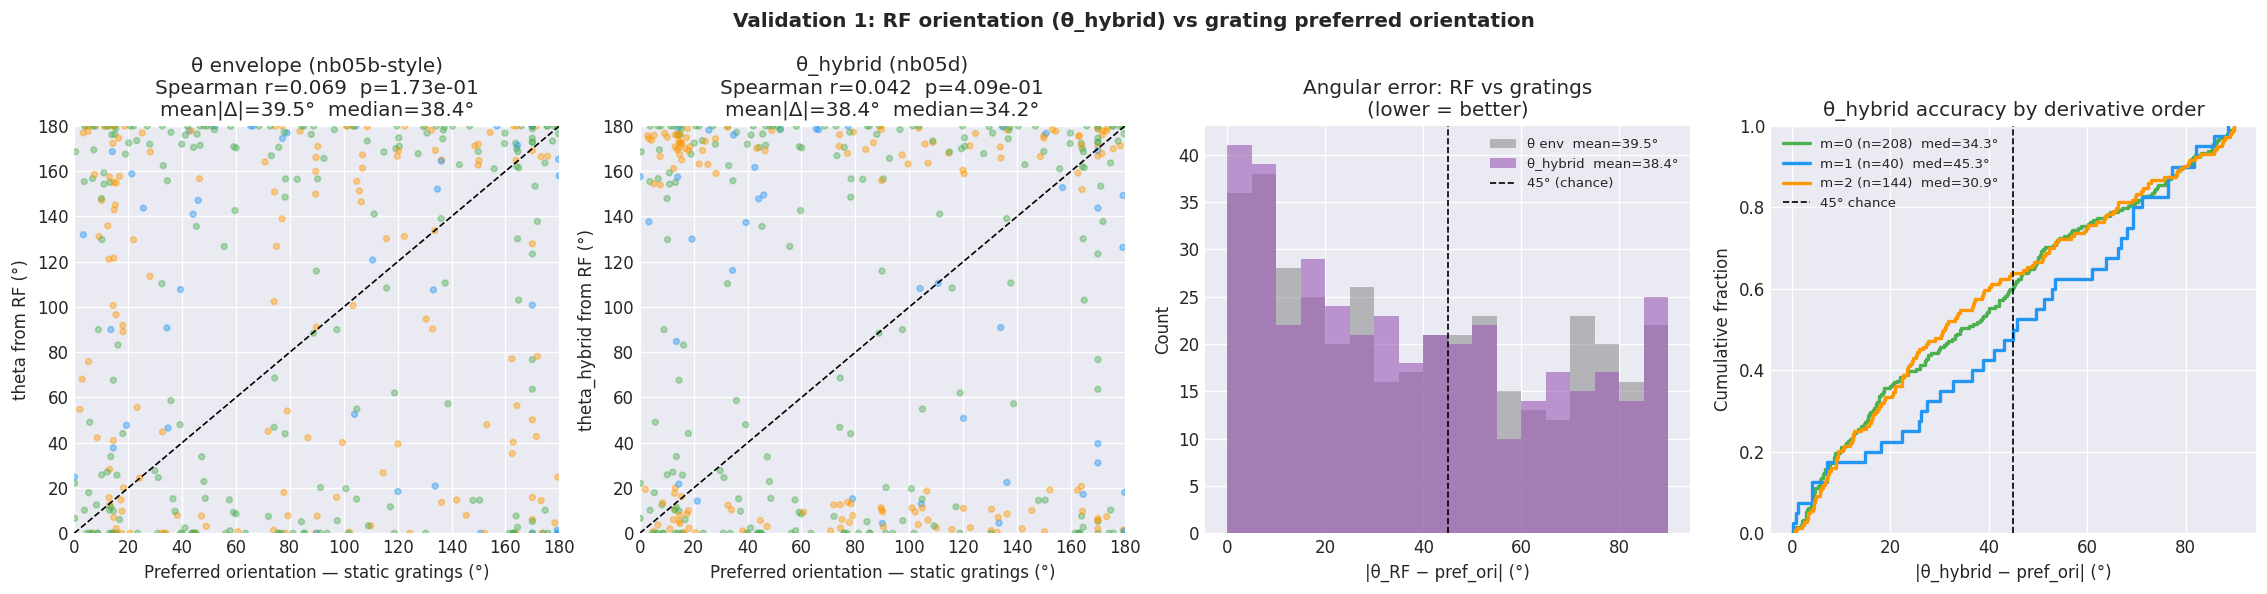

=== Orientation validation ===
  θ envelope            n=392  mean|Δ|=39.5°  r=0.069  p=1.73e-01  <45°: 58%
  θ_hybrid              n=392  mean|Δ|=38.4°  r=0.042  p=4.09e-01  <45°: 61%


In [20]:
# ---------------------------------------------------------------------------
# Fig 1: θ_hybrid vs preferred orientation from static gratings
# The core validation — do our RF-based estimates match independent tuning?
# ---------------------------------------------------------------------------
ORDER_COLORS = {0: '#4CAF50', 1: '#2196F3', 2: '#FF9800'}

def circular_diff_ori(a, b):
    """Smallest angular difference between two orientations in [0,180°)."""
    d = np.abs(a - b)
    return np.minimum(d, 180 - d)

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
fig.suptitle('Validation 1: RF orientation (θ_hybrid) vs grating preferred orientation',
             fontsize=12, fontweight='bold')

for ax, orient_col, col, label in [
    (axes[0], 'theta',        'grey',    'θ envelope (nb05b-style)'),
    (axes[1], 'theta_hybrid', '#9b59b6', 'θ_hybrid (nb05d)'),
]:
    sub = merged_ori.dropna(subset=[orient_col, 'pref_ori'])
    diff = circular_diff_ori(sub[orient_col], sub['pref_ori'])
    r, p = spearmanr(sub[orient_col], sub['pref_ori'])
    ax.scatter(sub['pref_ori'], sub[orient_col],
               c=[ORDER_COLORS.get(m, 'grey')
                  for m in sub['derivative_order']],
               s=12, alpha=0.4)
    ax.plot([0,180],[0,180], 'k--', lw=1)
    ax.set_xlabel('Preferred orientation — static gratings (°)')
    ax.set_ylabel(f'{orient_col} from RF (°)')
    ax.set_title(f'{label}\nSpearman r={r:.3f}  p={p:.2e}\n'
                 f'mean|Δ|={diff.mean():.1f}°  median={diff.median():.1f}°')
    ax.set_xlim(0, 180); ax.set_ylim(0, 180)

# Circular difference histogram: θ vs θ_hybrid
ax = axes[2]
sub_all = merged_ori.dropna(subset=['theta', 'theta_hybrid', 'pref_ori'])
diff_env = circular_diff_ori(sub_all['theta'],        sub_all['pref_ori'])
diff_hyb = circular_diff_ori(sub_all['theta_hybrid'], sub_all['pref_ori'])
bins = np.linspace(0, 90, 19)
ax.hist(diff_env, bins=bins, alpha=0.5, color='grey',
        label=f'θ env  mean={diff_env.mean():.1f}°')
ax.hist(diff_hyb, bins=bins, alpha=0.6, color='#9b59b6',
        label=f'θ_hybrid  mean={diff_hyb.mean():.1f}°')
ax.axvline(45, color='black', ls='--', lw=1, label='45° (chance)')
ax.set_xlabel('|θ_RF − pref_ori| (°)')
ax.set_ylabel('Count')
ax.set_title('Angular error: RF vs gratings\n(lower = better)')
ax.legend(fontsize=8)

# By order
ax = axes[3]
for m, col in ORDER_COLORS.items():
    sub_m = merged_ori[merged_ori['derivative_order'] == m].dropna(
        subset=['theta_hybrid','pref_ori'])
    if len(sub_m) < 3:
        continue
    d = circular_diff_ori(sub_m['theta_hybrid'], sub_m['pref_ori'])
    ax.ecdf(d, label=f'm={m} (n={len(sub_m)})  med={d.median():.1f}°',
            color=col, lw=2)
ax.axvline(45, color='black', ls='--', lw=1, label='45° chance')
ax.set_xlabel('|θ_hybrid − pref_ori| (°)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('θ_hybrid accuracy by derivative order')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(nb07_dir / 'fig_07_orientation_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Orientation validation ===')
for orient_col, label in [('theta', 'θ envelope'), ('theta_hybrid', 'θ_hybrid')]:
    sub = merged_ori.dropna(subset=[orient_col, 'pref_ori'])
    d   = circular_diff_ori(sub[orient_col], sub['pref_ori'])
    r, p = spearmanr(sub[orient_col], sub['pref_ori'])
    frac_45 = (d < 45).mean() * 100
    print(f'  {label:20s}  n={len(sub)}  mean|Δ|={d.mean():.1f}°  '
          f'r={r:.3f}  p={p:.2e}  <45°: {frac_45:.0f}%')


ValueError: array must not contain infs or NaNs

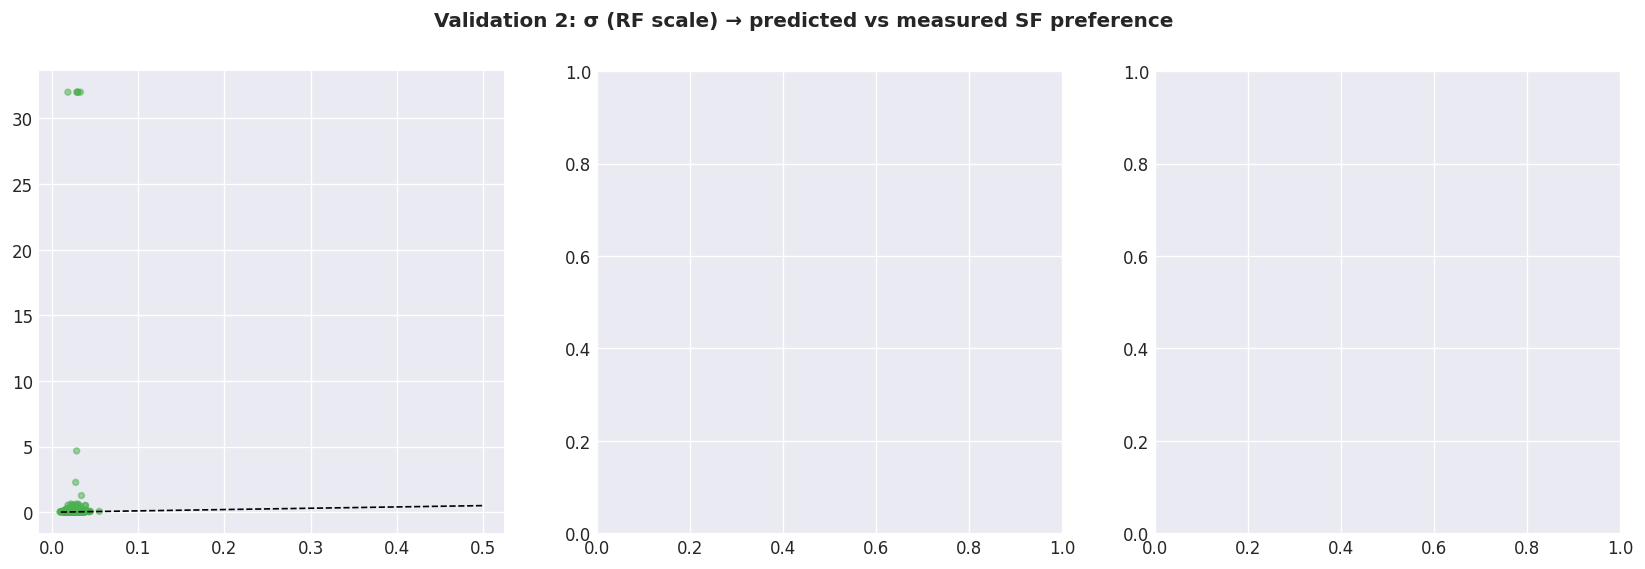

In [21]:
# ---------------------------------------------------------------------------
# Fig 2: σ → predicted SF vs measured preferred SF
# Prediction: SF_pref ≈ 1/(2πσ)
# ---------------------------------------------------------------------------
sub_sf = merged.dropna(subset=['sigma', 'pref_sf', 'sf_r_squared'])
sub_sf = sub_sf[sub_sf['pref_sf'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Validation 2: σ (RF scale) → predicted vs measured SF preference',
             fontsize=12, fontweight='bold')

# 2a. Scatter: predicted vs measured SF
ax = axes[0]
sc = ax.scatter(sub_sf['sf_predicted'], sub_sf['pref_sf'],
                c=[ORDER_COLORS.get(m, 'grey')
                   for m in sub_sf['derivative_order']],
                s=12, alpha=0.5)
sf_range = [0.01, 0.5]
ax.plot(sf_range, sf_range, 'k--', lw=1, label='y=x (perfect)')
r_sf, p_sf = pearsonr(np.log(sub_sf['sf_predicted']),
                       np.log(sub_sf['pref_sf']))
ax.set_xlabel('SF predicted from σ: 1/(2πσ)  [cpd]')
ax.set_ylabel('Preferred SF from gratings  [cpd]')
ax.set_title(f'SF prediction\nr(log-log)={r_sf:.3f}  p={p_sf:.2e}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(fontsize=8)

# 2b. σ vs measured pref_sf (log-log)
ax = axes[1]
for m, col in ORDER_COLORS.items():
    sub_m = sub_sf[sub_sf['derivative_order'] == m]
    if len(sub_m) < 3:
        continue
    ax.scatter(sub_m['sigma'], sub_m['pref_sf'],
               s=12, alpha=0.4, color=col, label=f'm={m} (n={len(sub_m)})')
# Overlay the 1/(2πσ) prediction line
sigma_range = np.linspace(sub_sf['sigma'].min(), sub_sf['sigma'].max(), 100)
ax.plot(sigma_range, 1/(2*np.pi*sigma_range), 'k-', lw=2,
        label='1/(2πσ) prediction')
r_s, p_s = pearsonr(np.log(sub_sf['sigma']), np.log(sub_sf['pref_sf']))
ax.set_xlabel('σ from RF (°)')
ax.set_ylabel('Preferred SF from gratings (cpd)')
ax.set_title(f'σ vs pref SF\nr(log-log)={r_s:.3f}  p={p_s:.2e}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(fontsize=8)

# 2c. SF prediction error by order
ax = axes[2]
sub_sf['log_ratio'] = np.log2(sub_sf['pref_sf'] / sub_sf['sf_predicted'])
ax.axvline(0, color='black', lw=1, ls='--', label='Perfect prediction')
for m, col in ORDER_COLORS.items():
    sub_m = sub_sf[sub_sf['derivative_order'] == m]['log_ratio'].dropna()
    if len(sub_m) < 3:
        continue
    ax.hist(sub_m, bins=20, alpha=0.55, color=col,
            label=f'm={m}  median={sub_m.median():.2f} oct')
ax.set_xlabel('log₂(pref_SF / predicted_SF)  [octaves]')
ax.set_ylabel('Count')
ax.set_title('SF prediction error by order\n'
             '(0 = perfect; >0 = higher SF than predicted)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(nb07_dir / 'fig_07_sf_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== SF validation ===')
print(f'n = {len(sub_sf)}')
print(f'r(log σ, log pref_SF) = {r_s:.3f}  p={p_s:.2e}')
print(f'r(log SF_pred, log pref_SF) = {r_sf:.3f}  p={p_sf:.2e}')
log_ratio = sub_sf['log_ratio']
print(f'Median prediction error: {log_ratio.median():.3f} octaves')
print(f'Mean |error|: {log_ratio.abs().mean():.3f} octaves')
print(f'Within 1 octave: {(log_ratio.abs() < 1).mean()*100:.0f}%')


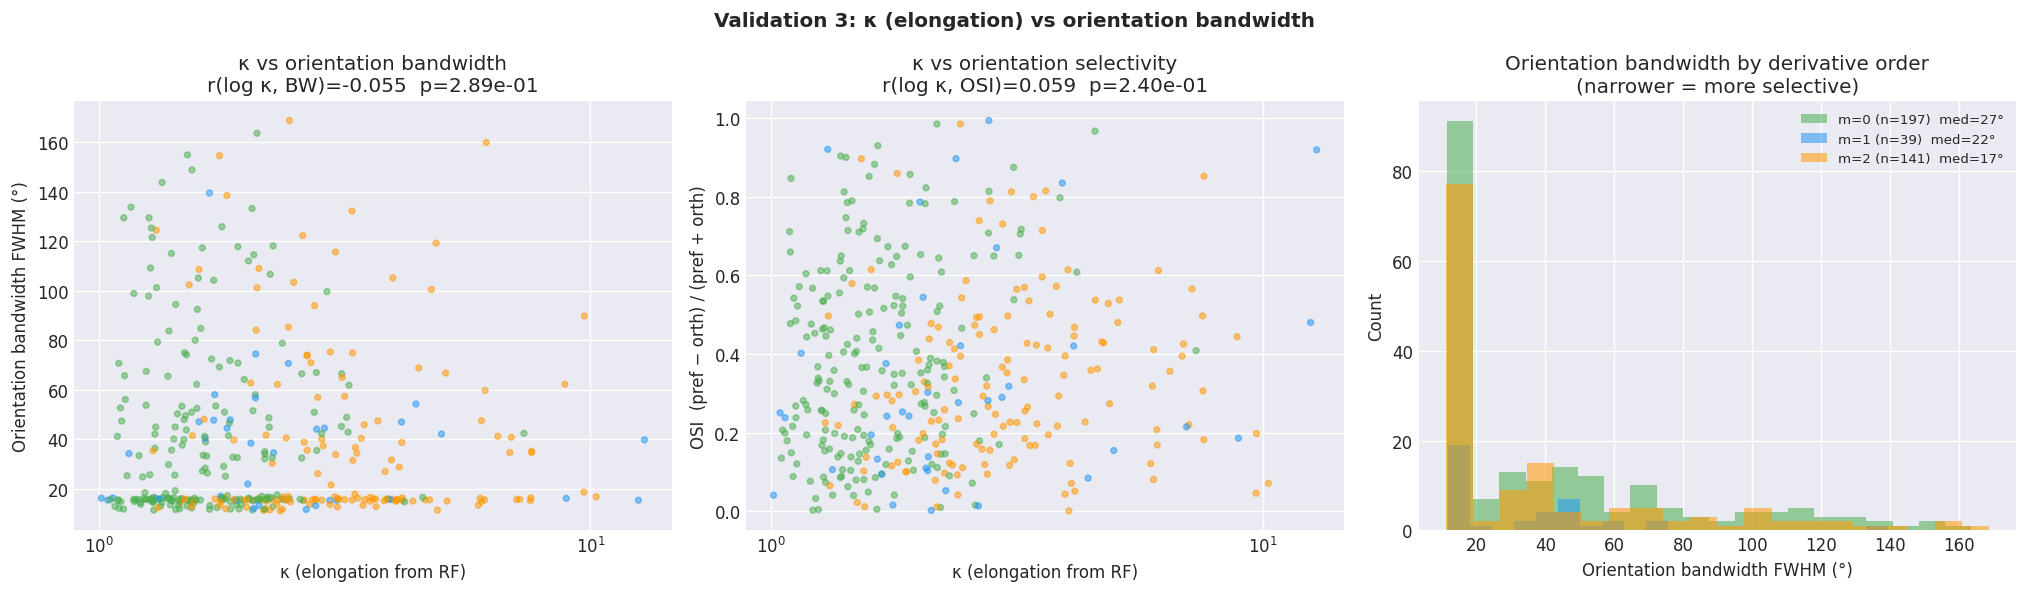

=== κ → bandwidth validation ===
n = 377
r(log κ, BW) = -0.055  p=2.89e-01
r(log κ, OSI) = 0.059  p=2.40e-01
  m=0  n=197  median BW=27.2°
  m=1  n=39  median BW=22.0°
  m=2  n=141  median BW=16.6°


In [22]:
# ---------------------------------------------------------------------------
# Fig 3: κ (elongation) vs orientation bandwidth from gratings
# Prediction: higher κ → narrower orientation tuning
# ---------------------------------------------------------------------------
sub_bw = merged_ori.dropna(subset=['kappa', 'ori_bandwidth']).copy()
sub_bw = sub_bw[sub_bw['ori_bandwidth'] < 180].copy()  # exclude flat tuning

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Validation 3: κ (elongation) vs orientation bandwidth',
             fontsize=12, fontweight='bold')

# 3a. Scatter κ vs bandwidth
ax = axes[0]
sc = ax.scatter(sub_bw['kappa'], sub_bw['ori_bandwidth'],
                c=[ORDER_COLORS.get(m, 'grey')
                   for m in sub_bw['derivative_order']],
                s=12, alpha=0.5)
r_kb, p_kb = pearsonr(np.log(sub_bw['kappa']),
                       sub_bw['ori_bandwidth'])
ax.set_xlabel('κ (elongation from RF)')
ax.set_ylabel('Orientation bandwidth FWHM (°)')
ax.set_title(f'κ vs orientation bandwidth\nr(log κ, BW)={r_kb:.3f}  p={p_kb:.2e}')
ax.set_xscale('log')

# 3b. κ vs OSI (orientation selectivity index)
ax = axes[1]
sub_osi = merged_ori.dropna(subset=['kappa', 'osi'])
sc = ax.scatter(sub_osi['kappa'], sub_osi['osi'],
                c=[ORDER_COLORS.get(m, 'grey')
                   for m in sub_osi['derivative_order']],
                s=12, alpha=0.5)
r_ko, p_ko = pearsonr(np.log(sub_osi['kappa']), sub_osi['osi'])
ax.set_xlabel('κ (elongation from RF)')
ax.set_ylabel('OSI  (pref − orth) / (pref + orth)')
ax.set_title(f'κ vs orientation selectivity\nr(log κ, OSI)={r_ko:.3f}  p={p_ko:.2e}')
ax.set_xscale('log')

# 3c. Bandwidth by order
ax = axes[2]
for m, col in ORDER_COLORS.items():
    sub_m = sub_bw[sub_bw['derivative_order'] == m]['ori_bandwidth'].dropna()
    if len(sub_m) < 3:
        continue
    ax.hist(sub_m, bins=20, alpha=0.55, color=col,
            label=f'm={m} (n={len(sub_m)})  med={sub_m.median():.0f}°')
ax.set_xlabel('Orientation bandwidth FWHM (°)')
ax.set_ylabel('Count')
ax.set_title('Orientation bandwidth by derivative order\n'
             '(narrower = more selective)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(nb07_dir / 'fig_07_bandwidth_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== κ → bandwidth validation ===')
print(f'n = {len(sub_bw)}')
print(f'r(log κ, BW) = {r_kb:.3f}  p={p_kb:.2e}')
print(f'r(log κ, OSI) = {r_ko:.3f}  p={p_ko:.2e}')
for m in [0, 1, 2]:
    sub_m = sub_bw[sub_bw['derivative_order'] == m]['ori_bandwidth'].dropna()
    print(f'  m={m}  n={len(sub_m)}  median BW={sub_m.median():.1f}°')


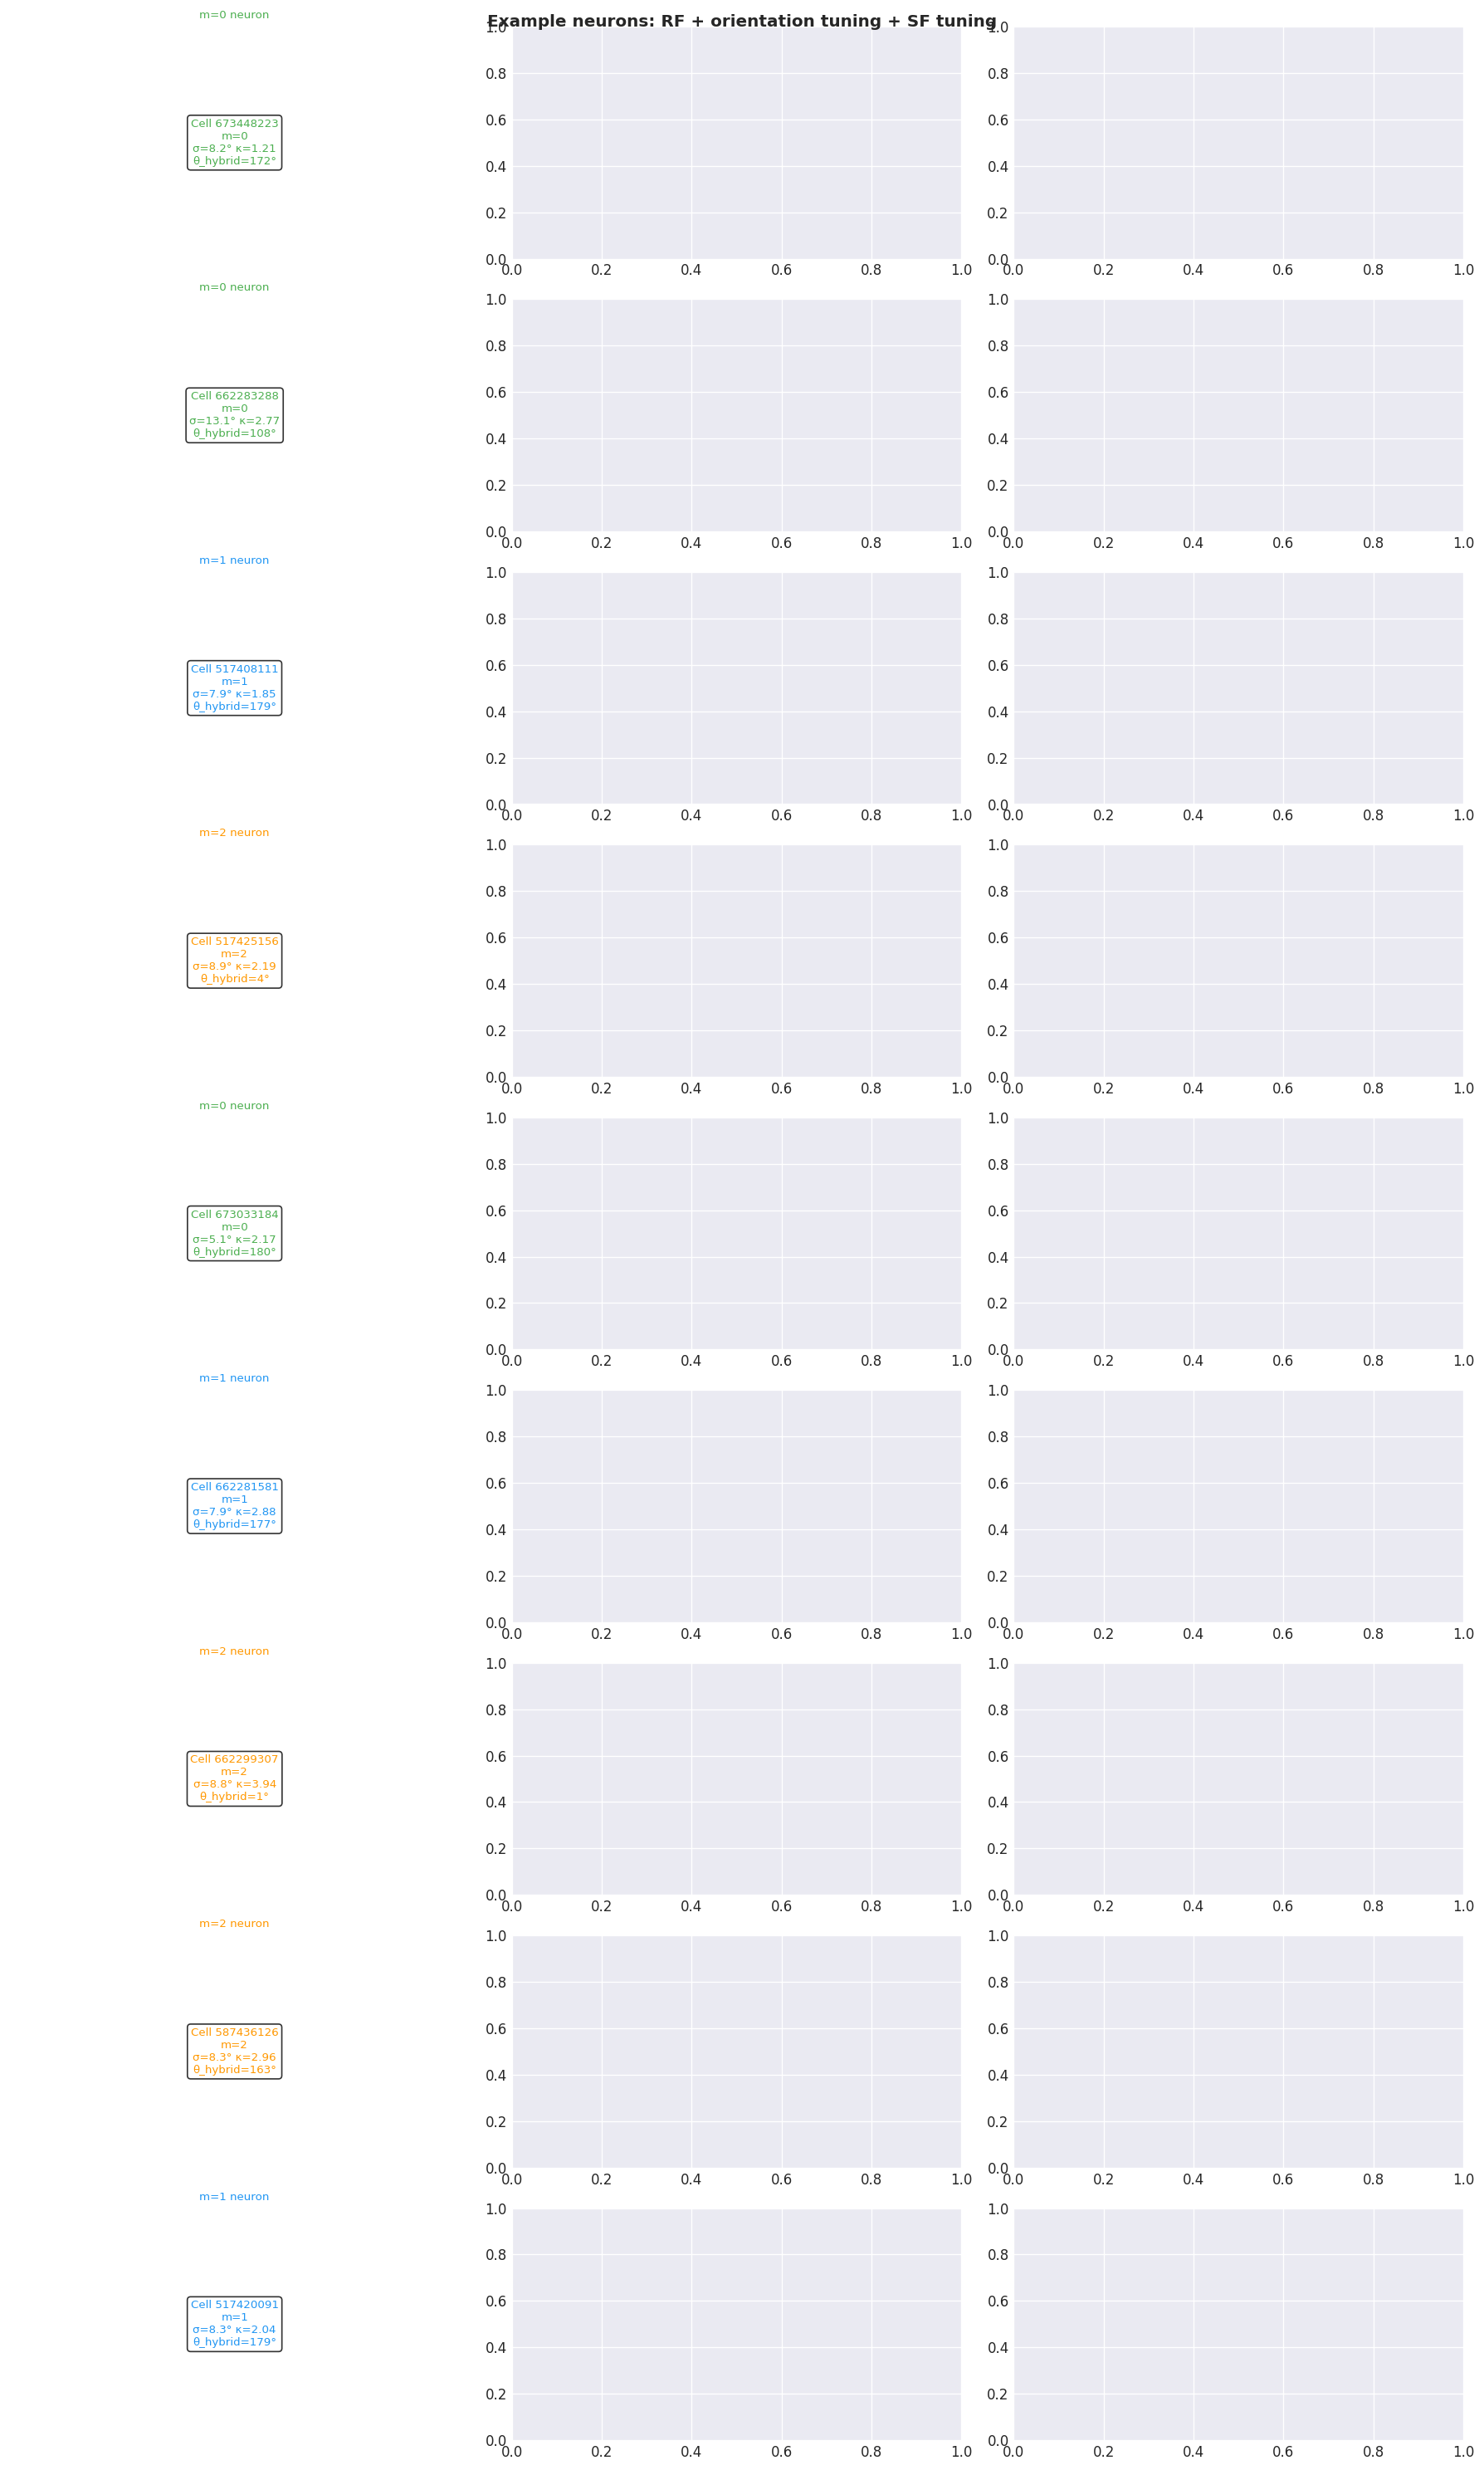

In [23]:
# ---------------------------------------------------------------------------
# Fig 4: Example neurons — RF map + tuning curves side by side
# Re-extracts tuning arrays for a handful of well-fit neurons
# ---------------------------------------------------------------------------
# Pick 8 neurons: 2-3 per order, highest ori_r_squared
best_neurons = (merged_ori
                .sort_values('ori_r_squared', ascending=False)
                .groupby('derivative_order')
                .head(3)
                .reset_index(drop=True))

# Re-load Session A datasets (cache already open from loop above)
_dataset_cache = {}
def _get_sessA(container_id):
    if container_id not in _dataset_cache:
        _dataset_cache[container_id] = boc.get_ophys_experiment_data(
            container_to_sessA[container_id])
    return _dataset_cache[container_id]

n_neurons = len(best_neurons)
fig, axes = plt.subplots(n_neurons, 3, figsize=(15, n_neurons * 2.8))
fig.suptitle('Example neurons: RF + orientation tuning + SF tuning',
             fontsize=12, fontweight='bold')

for row_i, (_, nr) in enumerate(best_neurons.iterrows()):
    cid = int(nr['cell_id'])
    m   = int(nr['derivative_order'])
    col = ORDER_COLORS.get(m, 'grey')

    # Re-extract tuning arrays
    try:
        ds      = _get_sessA(nr['container_id'])
        results = extract_grating_tuning(ds, [cid])
        rec     = results[0]
        ori_arr = rec.get('mean_responses_ori', np.full(6, np.nan))
        sf_arr  = rec.get('mean_responses_sf',  np.full(5, np.nan))
    except Exception:
        ori_arr = np.full(6, np.nan)
        sf_arr  = np.full(5, np.nan)

    # Col 0: RF from nb05d (load from ridge)
    ax = axes[row_i, 0] if n_neurons > 1 else axes[0]
    # Try loading RF map from batch_get_rf_maps_safe output
    # (use a simple placeholder if not available)
    ax.text(0.5, 0.5, f'Cell {cid}\nm={m}\n'
            f'σ={nr["sigma"]:.1f}° κ={nr["kappa"]:.2f}\n'
            f'θ_hybrid={nr["theta_hybrid"]:.0f}°',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=8, color=col,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    ax.set_title(f'm={m} neuron', fontsize=8, color=col)
    ax.axis('off')

    # Col 1: orientation tuning
    ax = axes[row_i, 1] if n_neurons > 1 else axes[1]
    if np.any(np.isfinite(ori_arr)):
        ax.bar(STATIC_GRATING_ORIENTATIONS, ori_arr,
               width=25, color=col, alpha=0.7, edgecolor='white')
        if np.isfinite(nr.get('pref_ori', np.nan)):
            ax.axvline(nr['pref_ori'], color='black', ls='--', lw=1.5,
                       label=f'pref={nr["pref_ori"]:.0f}°')
        ax.set_xlabel('Orientation (°)')
        ax.set_ylabel('ΔF/F')
        ax.set_title(f'Ori tuning  R²={nr["ori_r_squared"]:.2f}\n'
                     f'pref={nr.get("pref_ori",np.nan):.0f}°  '
                     f'BW={nr.get("ori_bandwidth",np.nan):.0f}°', fontsize=8)
        ax.legend(fontsize=7)

    # Col 2: SF tuning
    ax = axes[row_i, 2] if n_neurons > 1 else axes[2]
    if np.any(np.isfinite(sf_arr)):
        ax.semilogx(STATIC_GRATING_FREQUENCIES, sf_arr,
                    'o-', color=col, alpha=0.8, lw=2)
        if np.isfinite(nr.get('pref_sf', np.nan)):
            ax.axvline(nr['pref_sf'], color='black', ls='--', lw=1.5,
                       label=f'pref={nr["pref_sf"]:.3f} cpd')
        ax.axvline(nr['sf_predicted'], color='red', ls=':', lw=1.5,
                   label=f'pred={nr["sf_predicted"]:.3f} cpd')
        ax.set_xlabel('SF (cpd)')
        ax.set_ylabel('ΔF/F')
        ax.set_title(f'SF tuning\npref={nr.get("pref_sf",np.nan):.3f} cpd  '
                     f'pred={nr["sf_predicted"]:.3f} cpd', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(nb07_dir / 'fig_07_example_neurons.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# ---------------------------------------------------------------------------
# Validation summary
# ---------------------------------------------------------------------------
print('=' * 65)
print('STATIC GRATINGS VALIDATION SUMMARY')
print('=' * 65)
print(f'\nNeurons with RF parameters (nb05d):  {len(rf_df):,}')
print(f'Neurons with grating tuning:          {len(gt_df):,}')
print(f'Matched (RF ∩ gratings):              {len(merged):,}')
print(f'Passing ori QC (R²≥{ORI_R2_THRESHOLD}):          {len(merged_ori):,}')

print(f'\n--- Prediction 1: θ_hybrid ≈ pref_ori ---')
sub = merged_ori.dropna(subset=['theta_hybrid', 'pref_ori'])
d   = circular_diff_ori(sub['theta_hybrid'], sub['pref_ori'])
r, p = spearmanr(sub['theta_hybrid'], sub['pref_ori'])
print(f'  n={len(sub)}  r={r:.3f}  p={p:.2e}')
print(f'  mean|Δ|={d.mean():.1f}°  median|Δ|={d.median():.1f}°')
print(f'  within 30°: {(d<30).mean()*100:.0f}%  within 45°: {(d<45).mean()*100:.0f}%')

print(f'\n--- Prediction 2: σ → SF (1/2πσ) ---')
sub2 = merged.dropna(subset=['sigma','pref_sf'])
sub2 = sub2[sub2['pref_sf'] > 0]
r2, p2 = pearsonr(np.log(sub2['sigma']), np.log(sub2['pref_sf']))
lr = np.log2(sub2['pref_sf'] / sub2['sf_predicted'])
print(f'  n={len(sub2)}  r(log σ, log SF)={r2:.3f}  p={p2:.2e}')
print(f'  median prediction error={lr.median():.3f} oct  '
      f'within 1 oct: {(lr.abs()<1).mean()*100:.0f}%')

print(f'\n--- Prediction 3: κ → orientation bandwidth ---')
sub3 = merged_ori.dropna(subset=['kappa','ori_bandwidth'])
sub3 = sub3[sub3['ori_bandwidth'] < 180]
r3, p3 = pearsonr(np.log(sub3['kappa']), sub3['ori_bandwidth'])
print(f'  n={len(sub3)}  r(log κ, BW)={r3:.3f}  p={p3:.2e}')

print(f'\n--- m=2 horizontal bias cross-validation ---')
sub_m2 = merged_ori[merged_ori['derivative_order'] == 2].dropna(
    subset=['theta_hybrid', 'pref_ori'])
if len(sub_m2) > 5:
    horiz_rf    = ((sub_m2['theta_hybrid'] < 20) |
                   (sub_m2['theta_hybrid'] > 160)).mean() * 100
    horiz_grat  = ((sub_m2['pref_ori'] < 20) |
                   (sub_m2['pref_ori'] > 160)).mean() * 100
    d_m2        = circular_diff_ori(sub_m2['theta_hybrid'], sub_m2['pref_ori'])
    print(f'  m=2 n={len(sub_m2)}')
    print(f'  Horizontal via θ_hybrid: {horiz_rf:.0f}%')
    print(f'  Horizontal via gratings: {horiz_grat:.0f}%')
    print(f'  Agreement mean|Δ|={d_m2.mean():.1f}°')
    if horiz_grat > 60:
        print('  → m=2 horizontal bias CONFIRMED by independent grating measurement ✓')
    else:
        print('  → m=2 horizontal bias NOT confirmed by gratings — revisit φ estimator')

# Save merged results
merged.to_csv(nb07_dir / 'rf_grating_merged.csv', index=False)
print(f'\nSaved merged dataset → {nb07_dir}/rf_grating_merged.csv')

# ── m=0 only repeat ────────────────────────────────────────────────
print('\n--- m=0 only ---')
sub_m0 = merged_m0_ori.dropna(subset=['theta_hybrid', 'pref_ori'])
d_m0   = circular_diff_ori(sub_m0['theta_hybrid'], sub_m0['pref_ori'])
r_m0, p_m0 = spearmanr(sub_m0['theta_hybrid'], sub_m0['pref_ori'])
print(f'  n={len(sub_m0)}  r={r_m0:.3f}  p={p_m0:.3f}  '
      f'mean|Δ|={d_m0.mean():.1f}°  within 30°: {(d_m0<30).mean()*100:.0f}%')


STATIC GRATINGS VALIDATION SUMMARY

Neurons with RF parameters (nb05d):  885
Neurons with grating tuning:          545
Matched (RF ∩ gratings):              545
Passing ori QC (R²≥0.3):          392

--- Prediction 1: θ_hybrid ≈ pref_ori ---
  n=392  r=0.042  p=4.09e-01
  mean|Δ|=38.4°  median|Δ|=34.2°
  within 30°: 45%  within 45°: 61%

--- Prediction 2: σ → SF (1/2πσ) ---
  n=545  r(log σ, log SF)=-0.045  p=2.96e-01
  median prediction error=0.893 oct  within 1 oct: 25%

--- Prediction 3: κ → orientation bandwidth ---
  n=377  r(log κ, BW)=-0.055  p=2.89e-01

--- m=2 horizontal bias cross-validation ---
  m=2 n=144
  Horizontal via θ_hybrid: 94%
  Horizontal via gratings: 47%
  Agreement mean|Δ|=37.3°
  → m=2 horizontal bias NOT confirmed by gratings — revisit φ estimator

Saved merged dataset → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/gratings_validation/rf_grating_merged.csv

--- m=0 only ---
  n=208  r=0.119  p=0.086  mean|Δ|=38.0°  within 30°: 45%
